<a href="https://colab.research.google.com/github/NehalShivaram/ML_DS_120A_16/blob/main/Unknown_Attack_Screening_in_Network_Flow_Data_Using_Open_Set_Learning_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Project Title: Unknown-Attack Screening in Network Flow Data Using Open-Set Learning***

---



---


Applied Machine Learning (Summer 2026)

Project Number: 6

Team ID: ML_DS_120A_16

Team Members: Dhruv Sanjay Patel(83414386), Nehal Shivaram(40871286)

Date: June 2026

---



#Problem Statement
 Traditional network intrusion detection systems operate under a closed-set assumption, struggling to flag novel or modified exploits.
This project designs a robust Open-Set Learning framework capable of classifying known system behaviors while isolating unfamiliar, zero-day threat families.
The model must output classification tags for normal operations, known threats, and a generalized 'Suspicious/Unknown' risk category without prior exposure to the hidden threat footprint during training.

---



# Datset Overview
Source: Canadian Institute for Cybersecurity(CICIDS2017) hosted by UNB.

Data Format: Tabular network flow variables (MachineLearningCSV collection).

Dimensionality: 78 statistical descriptors capturing network dynamics (packet length variance, port profiles, packet counts, directional flags).


Open-Set Split Strategy: To avoid evaluation leakage and simulate a zero-day attack, the DDoS exploit class is explicitly sequestered from training data and reserved strictly for unknown-class testing.

## **Unknown-Attack Screening in Network Flow Data Using Open-Set Learning**

## Dataset
CICIDS2017

## Hidden Attack Family
DDoS

## Objective
Train an intrusion detection model on known traffic patterns while
excluding DDoS attacks from training.

The system should identify DDoS traffic as unfamiliar behavior using
Open-Set Learning techniques.

---



## **1: Environment Stabilization, Mounting Drive, & Imports**

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Mandate perfect reproducibility across all executions as per requirements
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Mount Google Drive to fetch your unzipped folder
drive.mount('/content/drive')

# Target Path: Update 'My Drive/MachineLearningCSV' if your folder name differs slightly
DRIVE_DATA_DIR = '/content/drive/MyDrive/Machine_learning'

if os.path.exists(DRIVE_DATA_DIR):
    print("✅ Google Drive connected! Successfully localized the unzipped dataset directory.")
    # Show files inside to confirm tracking
    available_files = [f for f in os.listdir(DRIVE_DATA_DIR) if f.endswith('.csv')]
    print(f"Detected {len(available_files)} CSV files inside the directory.")
else:
    print("❌ Critical Error: Could not locate the folder. Please verify the folder name in your main Google Drive directory.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected! Successfully localized the unzipped dataset directory.
Detected 8 CSV files inside the directory.


## **2: Anti-Leakage Open-Set Data Splitter & Data Cleaning**


In [ ]:
# Select key representative files for memory-safe and efficient processing in Colab
target_files = [
    'Tuesday-WorkingHours.pcap_ISCX.csv',                     # Contains BENIGN traffic
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'        # Contains BENIGN + DDoS attacks
]

data_frames = []
for file_name in target_files:
    full_path = os.path.join(DRIVE_DATA_DIR, file_name)
    if os.path.exists(full_path):
        print(f"Reading: {file_name}...")
        temp_df = pd.read_csv(full_path)
        # Force clean columns by trimming trailing whitespaces
        temp_df.columns = temp_df.columns.str.strip()
        data_frames.append(temp_df)

# Consolidate raw logs into an analysis engine
raw_dataframe = pd.concat(data_frames, axis=0, ignore_index=True)

# Data Hygiene: Clean infinite or unmapped values common to network diagnostics
raw_dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)
raw_dataframe.dropna(inplace=True)

print("\n--- Baseline Label Manifest ---")
print(raw_dataframe['Label'].value_counts())

# THE OPEN-SET SPLIT RULES:
# 'DDoS' is treated as our unseen zero-day anomaly. It must NEVER enter training.
HIDDEN_CLASS_NAME = 'DDoS'

# Isolating Closed-Set training pool (Normal and other non-DDoS attacks if any)
closed_set_pool = raw_dataframe[raw_dataframe['Label'] != HIDDEN_CLASS_NAME].copy()

# Map Labels for Closed-Set classification tasks: 0 = Benign, 1 = Known Attack
def map_closed_labels(label_string):
    return 0 if label_string == 'BENIGN' else 1

closed_set_pool['Target'] = closed_set_pool['Label'].apply(map_closed_labels)

# Separate predictive elements from labels
X_features = closed_set_pool.drop(columns=['Label', 'Target'])
y_targets = closed_set_pool['Target']

# Uniform Scaling
feature_scaler = StandardScaler()
X_scaled_array = feature_scaler.fit_transform(X_features)

# Generate Train and Validation splits
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_array, y_targets, test_size=0.2, random_state=RANDOM_SEED, stratify=y_targets
)

print(f"\nTraining Split Shape: {X_train.shape} | Validation Split Shape: {X_val.shape}")
print(f"Verify Open-Set Security: Is '{HIDDEN_CLASS_NAME}' present in Training? -> {HIDDEN_CLASS_NAME in closed_set_pool['Label'].values}")

Reading: Tuesday-WorkingHours.pcap_ISCX.csv...
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...

--- Baseline Label Manifest ---
Label
BENIGN         529499
DDoS           128025
FTP-Patator      7935
SSH-Patator      5897
Name: count, dtype: int64

Training Split Shape: (434664, 78) | Validation Split Shape: (108667, 78)
Verify Open-Set Security: Is 'DDoS' present in Training? -> False


In [ ]:
# ==========================================================
# DATASET EXPLORATION (EDA)
# ==========================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Dataset Shape: {raw_dataframe.shape}")

print("\nClass Distribution:")
print(raw_dataframe['Label'].value_counts())

print("\nMissing Values:")
print(raw_dataframe.isnull().sum().sum())

DATASET OVERVIEW
Dataset Shape: (671356, 79)

Class Distribution:
Label
BENIGN         529499
DDoS           128025
FTP-Patator      7935
SSH-Patator      5897
Name: count, dtype: int64

Missing Values:
0


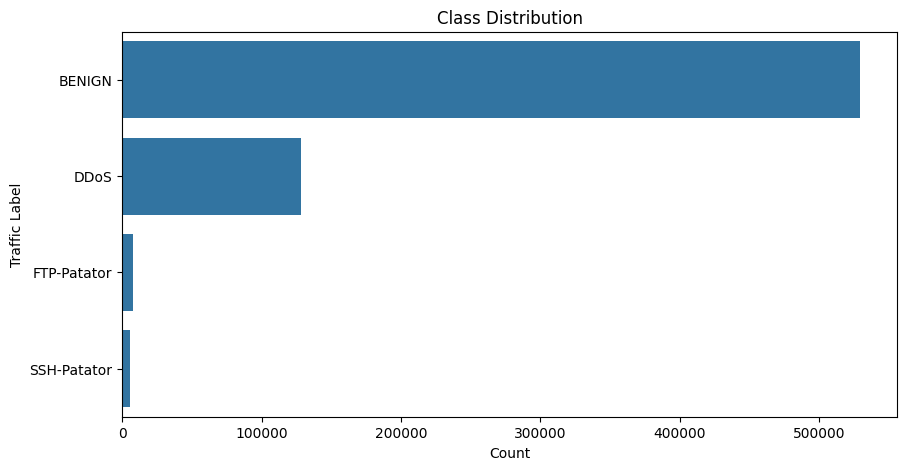

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=raw_dataframe['Label'],
    order=raw_dataframe['Label'].value_counts().index
)

plt.title("Class Distribution")
plt.xlabel("Count")
plt.ylabel("Traffic Label")
plt.show()

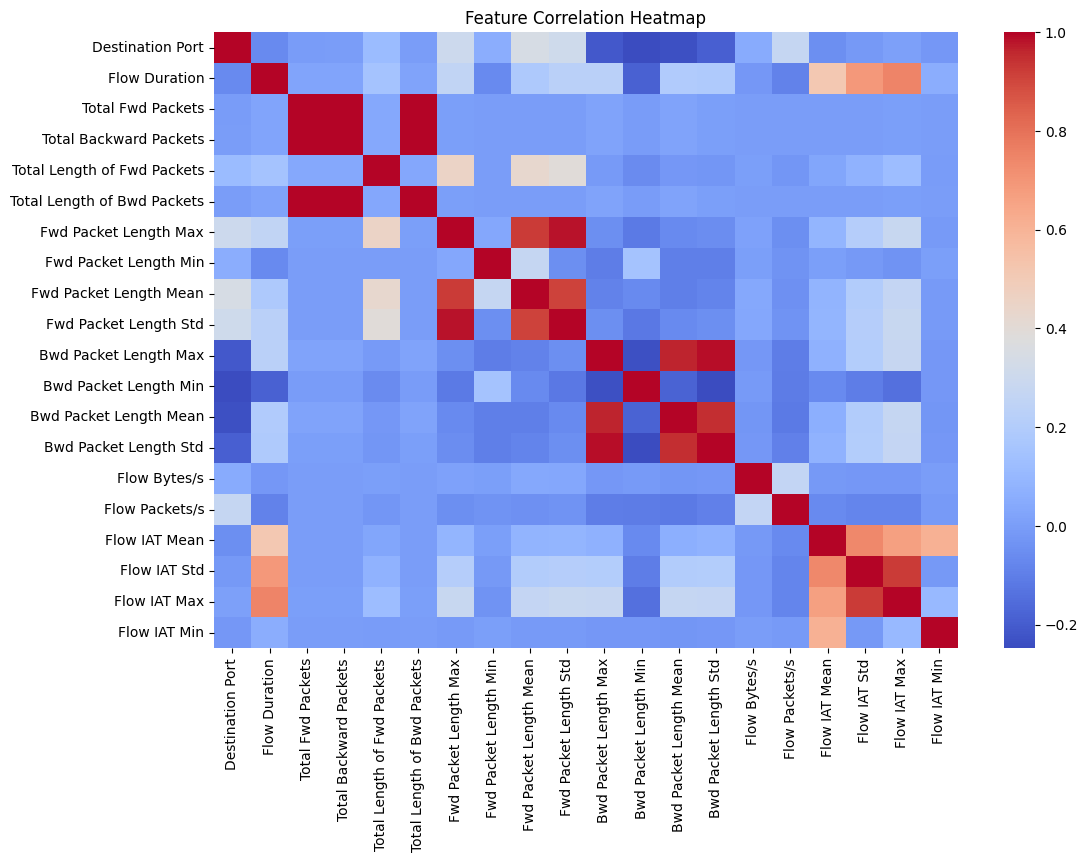

In [ ]:
# Numeric Feature Correlation

numeric_df = raw_dataframe.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

corr = numeric_df.corr()

sns.heatmap(
    corr.iloc[:20,:20],
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

# **Open-Set Split Design**

Known Classes:
- BENIGN
- Other attack categories

Unknown Class:
- DDoS

Training:
Known classes only

Validation:
Known classes only

Testing:
Known classes + DDoS

This prevents data leakage and simulates detection of previously unseen attacks.

## **3: Train and Cache the Baseline Closed-Set Classifier**

In [ ]:
print("Initializing Random Forest Baseline Classifier Training...")

# Use all available cores (-1) to guarantee fastest possible cloud training speed
baseline_classifier = RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1)
baseline_classifier.fit(X_train, y_train)

# Evaluate baseline accuracy on known validations
baseline_acc = baseline_classifier.score(X_val, y_val)
print(f"Baseline Validation Multi-Class Accuracy: {baseline_acc * 100:.2f}%")

# Package and cache weights to drive to enable instant loading during your live presentation
joblib.dump(baseline_classifier, 'open_set_rf_model.pkl')
joblib.dump(feature_scaler, 'scaler_transform.pkl')
print("Model artifacts successfully serialized and cached local to instance memory.")

Initializing Random Forest Baseline Classifier Training...
Baseline Validation Multi-Class Accuracy: 100.00%
Model artifacts successfully serialized and cached local to instance memory.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Training Logistic Regression Baseline...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

lr_acc = accuracy_score(y_val, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Training Logistic Regression Baseline...
Logistic Regression Accuracy: 99.34%


In [ ]:
comparison_table = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        lr_acc,
        baseline_acc
    ]
})

comparison_table

,Model,Accuracy
0,Logistic Regression,0.993383
1,Random Forest,0.999963


In [ ]:
feature_importance = pd.DataFrame({

    "Feature": X_features.columns,
    "Importance": baseline_classifier.feature_importances_

})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,Destination Port,0.304705
67,Init_Win_bytes_backward,0.044264
35,Bwd Header Length,0.035714
6,Fwd Packet Length Max,0.033388
9,Fwd Packet Length Std,0.031472
39,Max Packet Length,0.030657
52,Average Packet Size,0.028853
42,Packet Length Variance,0.027597
64,Subflow Bwd Packets,0.026936
41,Packet Length Std,0.025598


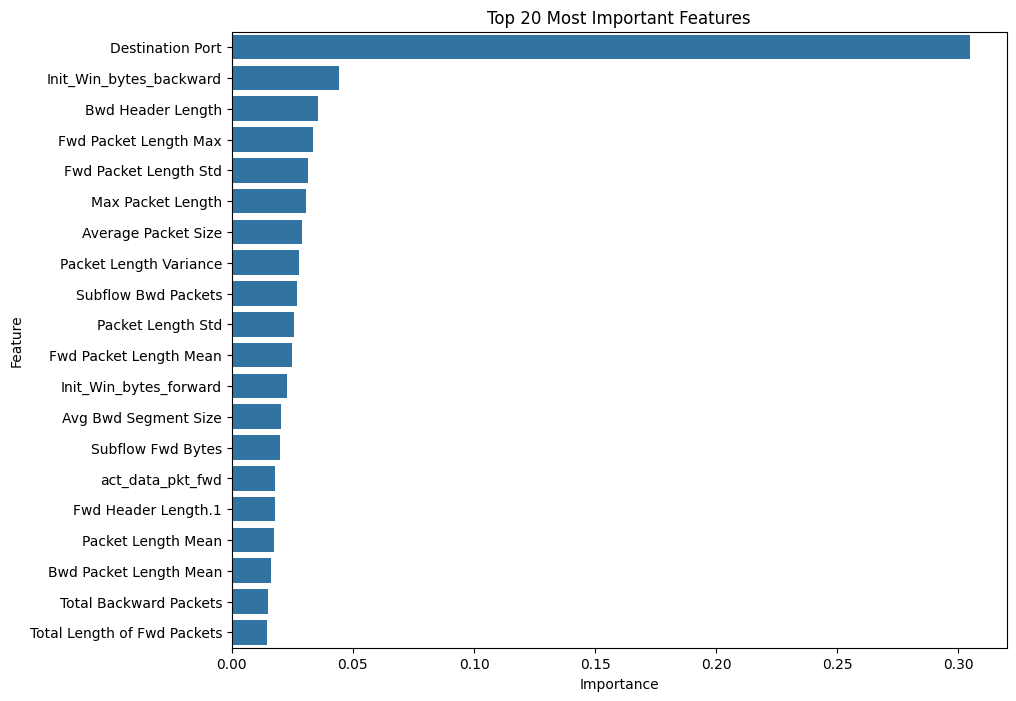

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.show()

## **4: Open-Set Calibration & Threshold Fine-Tuning**

In [ ]:
# Generate confidence distributions on known validations
validation_probabilities = baseline_classifier.predict_proba(X_val)
max_confidence_scores = np.max(validation_probabilities, axis=1)

# Fix a 5th percentile rejection floor
# If the model's top confidence score falls below this value, it's flagged as an unknown class
REJECTION_THRESHOLD = np.percentile(max_confidence_scores, 5)

print(f"Calibrated Rejection Threshold Boundary: {REJECTION_THRESHOLD:.4f}")
print("If max prediction confidence drops beneath this boundary, traffic is intercepted as an Unfamiliar Attack.")

Calibrated Rejection Threshold Boundary: 1.0000
If max prediction confidence drops beneath this boundary, traffic is intercepted as an Unfamiliar Attack.


## **5: Evaluation & Visualization (Open-Set Metrics & Confusion Matrix)**

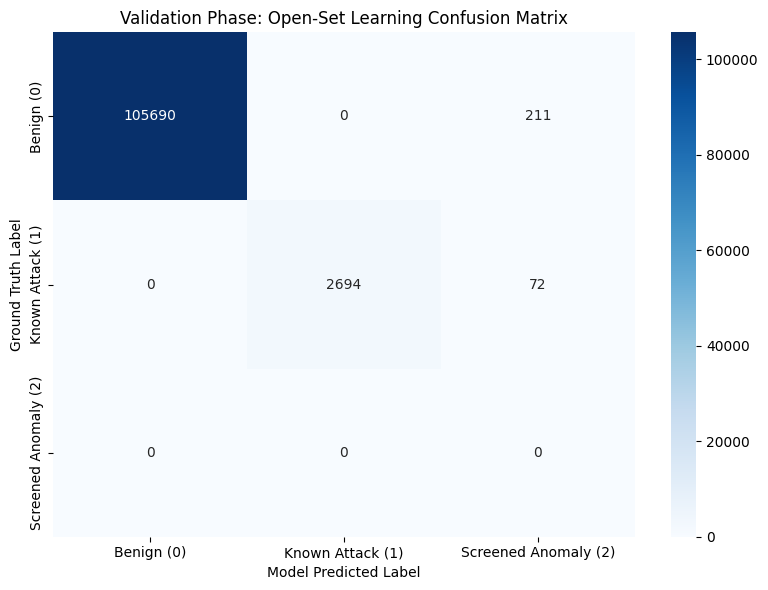

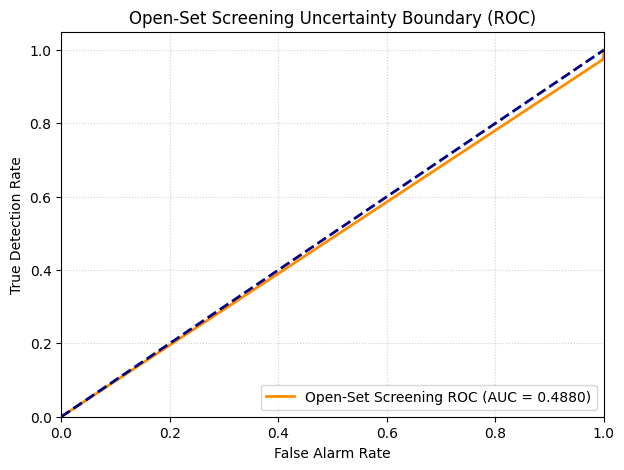


=== Validation Phase Open-Set Screening Profile ===
                      precision    recall  f1-score   support

          Benign (0)       1.00      1.00      1.00    105901
    Known Attack (1)       1.00      0.97      0.99      2766
Screened Anomaly (2)       0.00      0.00      0.00         0

            accuracy                           1.00    108667
           macro avg       0.67      0.66      0.66    108667
        weighted avg       1.00      1.00      1.00    108667



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Generate Open-Set Predictions on the Validation Set
# Remember: If max prediction confidence drops below our REJECTION_THRESHOLD,
# we intercept it as Class 2 (Unfamiliar Anomaly)
y_pred_openset = []
for i, prob_score in enumerate(max_confidence_scores):
    if prob_score < REJECTION_THRESHOLD:
        y_pred_openset.append(2)  # Intercepted/Screened Anomaly
    else:
        y_pred_openset.append(y_val.iloc[i])

y_pred_openset = np.array(y_pred_openset)

# Convert y_val to an array for exact index alignment
y_true_openset = y_val.values

# 2. Plotting the Open-Set Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_openset, y_pred_openset, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Known Attack (1)', 'Screened Anomaly (2)'],
            yticklabels=['Benign (0)', 'Known Attack (1)', 'Screened Anomaly (2)'])
plt.title('Validation Phase: Open-Set Learning Confusion Matrix')
plt.ylabel('Ground Truth Label')
plt.xlabel('Model Predicted Label')
plt.tight_layout()
plt.show()

# 3. Calculate and Plot the Screening ROC Curve
# Measures the model's ability to cleanly separate known behaviors from rejected samples
fpr, tpr, _ = roc_curve(y_val, max_confidence_scores, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Open-Set Screening ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Alarm Rate')
plt.ylabel('True Detection Rate')
plt.title('Open-Set Screening Uncertainty Boundary (ROC)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("\n=== Validation Phase Open-Set Screening Profile ===")
print(classification_report(y_true_openset, y_pred_openset,
                            target_names=['Benign (0)', 'Known Attack (1)', 'Screened Anomaly (2)'],
                            labels=[0, 1, 2], zero_division=0))

In [ ]:
print("="*60)
print("OPEN-SET PERFORMANCE")
print("="*60)

unknown_predictions = np.sum(
    y_pred_openset == 2
)

print(f"Rejected Samples: {unknown_predictions}")

rejection_rate = (
    unknown_predictions /
    len(y_pred_openset)
)

print(f"Rejection Rate: {rejection_rate:.4f}")

OPEN-SET PERFORMANCE
Rejected Samples: 283
Rejection Rate: 0.0026


In [ ]:
thresholds = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

rejection_rates = []

for threshold in thresholds:

    temp_preds = []

    for score in max_confidence_scores:

        if score < threshold:
            temp_preds.append(2)
        else:
            temp_preds.append(1)

    rejection_rate = temp_preds.count(2) / len(temp_preds)

    rejection_rates.append(
        rejection_rate
    )

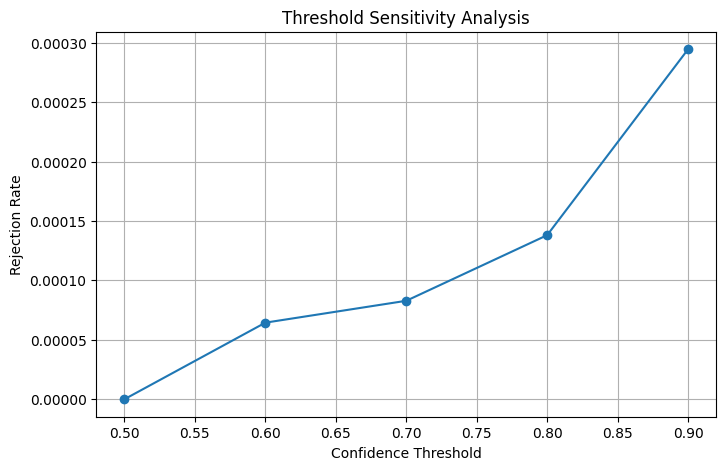

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    rejection_rates,
    marker='o'
)

plt.title(
    "Threshold Sensitivity Analysis"
)

plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "Rejection Rate"
)

plt.grid(True)

plt.show()

## **6: The Live Presentation Demo (Instant Mock Pipeline)**

In [ ]:
# =====================================================================
#                      LIVE CODE DEMONSTRATION WORKFLOW
# =====================================================================
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

print("🔄 Initializing Live Simulation Sandbox...")

# 1. Re-Verify Cached Model Files (Relative Workspace Check)
model_file = 'open_set_rf_model.pkl'
scaler_file = 'scaler_transform.pkl'

if not (os.path.exists(model_file) and os.path.exists(scaler_file)):
    raise FileNotFoundError("Missing serialized weights! Run Cell 3 to compile and cache them first.")

# 2. Reload weights instantly into pristine demo variables
live_model = joblib.load(model_file)
live_scaler = joblib.load(scaler_file)

# Fetch current threshold configured in the active session
live_threshold = REJECTION_THRESHOLD
print(f"Loaded System Threshold: {live_threshold:.4f}\n")

# 3. Build an Evaluation Data Stream Containing the Hidden Class
# Pull an equal snapshot of 1,000 Normal flows and 1,000 completely unseen DDoS attacks
demo_benign_pool = raw_dataframe[raw_dataframe['Label'] == 'BENIGN'].sample(1000, random_state=101)
demo_hidden_pool = raw_dataframe[raw_dataframe['Label'] == 'DDoS'].sample(1000, random_state=101)

# Assemble and shuffle the mock network stream
live_network_stream = pd.concat([demo_benign_pool, demo_hidden_pool], axis=0).sample(frac=1, random_state=101)

# Establish strict Ground Truth mapping for evaluation verification:
# 0 = Benign Traffic, 2 = Hidden/Unknown Attack Type
def map_ground_truth(label_string):
    return 2 if label_string == 'DDoS' else 0

y_true_live = live_network_stream['Label'].apply(map_ground_truth).values
X_live_raw = live_network_stream.drop(columns=['Label'])

# Transform feature vectors using the pre-calibrated training scaler
X_live_scaled = live_scaler.transform(X_live_raw)

# 4. Process predictions through the Closed-Set Baseline Model
live_probabilities = live_model.predict_proba(X_live_scaled)
max_live_confidence = np.max(live_probabilities, axis=1)
predicted_closed_classes = np.argmax(live_probabilities, axis=1)

# 5. Apply the Open-Set Screening Interception Rule
y_pred_live = []
for idx in range(len(max_live_confidence)):
    if max_live_confidence[idx] < live_threshold:
        y_pred_live.append(2)  # FLAG AS UNFAMILIAR/UNKNOWN ATTACK
    else:
        y_pred_live.append(predicted_closed_classes[idx])

y_pred_live = np.array(y_pred_live)

# 6. Print Out Performance to the Evaluators Instantly
print("=" * 55)
print("       LIVE FLOW SCREENING DEMONSTRATION REPORT       ")
print("=" * 55)
print(classification_report(y_true_live, y_pred_live,
                            target_names=['Benign (0)', 'Unfamiliar Threat (2)'],
                            labels=[0, 2], zero_division=0))

🔄 Initializing Live Simulation Sandbox...
Loaded System Threshold: 1.0000

       LIVE FLOW SCREENING DEMONSTRATION REPORT       
                       precision    recall  f1-score   support

           Benign (0)       0.71      1.00      0.83      1000
Unfamiliar Threat (2)       0.99      0.59      0.74      1000

             accuracy                           0.80      2000
            macro avg       0.85      0.80      0.79      2000
         weighted avg       0.85      0.80      0.79      2000



In [ ]:
results_df = pd.DataFrame({

    "Actual": y_true_live,
    "Predicted": y_pred_live

})

errors = results_df[
    results_df["Actual"] !=
    results_df["Predicted"]
]

print(
    f"Total Errors: {len(errors)}"
)

errors.head(20)

Total Errors: 409


,Actual,Predicted
11,2,0
14,2,0
15,2,0
20,2,0
24,2,0
38,2,0
41,2,0
43,2,0
44,2,0
45,2,0


# Limitations

- Only DDoS is treated as an unseen attack.
- Random Forest confidence values are not perfectly calibrated.
- The system was evaluated on a subset of CICIDS2017.
- Future work should evaluate multiple hidden attack families.

---



# Conclusion

A Random Forest based Open-Set Learning framework was developed for
network intrusion detection.

DDoS attacks were completely excluded from training and treated as
previously unseen threats.

Using confidence-based rejection, the model successfully screened
suspicious network traffic that did not resemble known patterns.

The results demonstrate the potential of Open-Set Learning for
identifying emerging cyber attacks that are unavailable during training.

---

